<a href="https://colab.research.google.com/github/ingkapat/Thai-Scam-Call-Detector/blob/main/diagnostics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers torchaudio scikit-learn seaborn tqdm librosa soundfile

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, glob, json, hashlib, re, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              f1_score, accuracy_score, roc_auc_score)
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

# === Paths (ตรงกับ prepare_split / train_*.ipynb) ===
DRIVE_BASE     = '/content/drive/MyDrive/ThaiScamCall'
ZIP_PATH       = f'{DRIVE_BASE}/mp3_15s.zip'
EXTRACT_DIR    = '/content/data_15s'
SPLITS_DIR     = f'{DRIVE_BASE}/splits'
RUNS_BASELINES = f'{DRIVE_BASE}/runs/baselines'
RUNS_TEXT      = f'{DRIVE_BASE}/runs/text_cls'
RUNS_E2E       = f'{DRIVE_BASE}/runs/e2e'
OUT_DIR        = f'{DRIVE_BASE}/runs/phase1_diagnostics'
os.makedirs(OUT_DIR, exist_ok=True)

CLASS_NAMES = ['not_scam', 'scam']

print('OK')

Device: cuda
OK


In [ ]:
# Extract zip (ใช้ใน step ที่ต้องโหลด audio จริง — 1.1B + 1.4)
import zipfile
if not os.path.exists(EXTRACT_DIR) or len(os.listdir(EXTRACT_DIR)) < 1000:
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
print('Audio files extracted:', len(os.listdir(EXTRACT_DIR)))

Audio files extracted: 21287


In [ ]:
# Load splits
splits = {s: pd.read_csv(f'{SPLITS_DIR}/{s}.csv') for s in ['train', 'val', 'test']}
for s, d in splits.items():
    print(f'{s:5s} n={len(d):>6} | {d.label.value_counts().to_dict()}')

test_df = splits['test'].reset_index(drop=True)
train_df = splits['train'].reset_index(drop=True)

train n= 17029 | {0: 8924, 1: 8105}
val   n=  2129 | {0: 1116, 1: 1013}
test  n=  2129 | {0: 1116, 1: 1013}


In [ ]:
# Auto-discover ทุก prediction file
predictions = {}
for root, prefix in [(RUNS_BASELINES, 'Baseline'), (RUNS_TEXT, 'TwoStage'), (RUNS_E2E, 'E2E')]:
    if not os.path.exists(root):
        continue
    for combo in sorted(os.listdir(root)):
        p = f'{root}/{combo}/test_predictions.csv'
        if os.path.exists(p):
            df = pd.read_csv(p)
            # align order กับ test.csv
            df = test_df[['filename', 'label']].merge(
                df[['filename', 'pred', 'prob_scam']], on='filename', how='left')
            predictions[f'{prefix}/{combo}'] = df

print(f'\nFound {len(predictions)} models:')
for k in predictions:
    print(f'  - {k}')

assert len(predictions) > 0, 'ไม่เจอ predictions เลย — เช็คว่ารัน train_*.ipynb แล้วยัง'


Found 9 models:
  - Baseline/majority
  - Baseline/mfcc_lr
  - Baseline/mfcc_rf
  - Baseline/random
  - Baseline/tfidf_lr_thonburian
  - TwoStage/thonburian_phayathai
  - E2E/wavlm
  - E2E/whisper_enc
  - E2E/xlsr


In [ ]:
# === Filter เฉพาะ 2 ===
FOCUS_MODELS_LIST = [
    'TwoStage/thonburian_phayathai',
    'E2E/whisper_enc',
]
predictions = {k: v for k, v in predictions.items() if k in FOCUS_MODELS_LIST}

print(f'>>> Filtered to {len(predictions)} focus models:')
for k in predictions:
    print(f'  - {k}')

missing = [m for m in FOCUS_MODELS_LIST if m not in predictions]
if missing:
    print(f'\n⚠️  Missing: {missing}')
    print('   เช็คว่า test_predictions.csv อยู่ครบที่:')
    for m in missing:
        prefix, combo = m.split('/')
        root = {'TwoStage': RUNS_TEXT, 'E2E': RUNS_E2E, 'Baseline': RUNS_BASELINES}[prefix]
        print(f'     {root}/{combo}/test_predictions.csv')

assert len(predictions) == 2, f'ต้องมีครบ 2 ตัว — ตอนนี้มี {len(predictions)}'

>>> Filtered to 2 focus models:
  - TwoStage/thonburian_phayathai
  - E2E/whisper_enc


In [ ]:
# === Summary table (เทียบทุก model) ===
rows = []
for name, d in predictions.items():
    y, p, s = d.label.values, d.pred.values, d.prob_scam.values
    rows.append({
        'model':           name,
        'accuracy':        accuracy_score(y, p),
        'macro_f1':        f1_score(y, p, average='macro'),
        'weighted_f1':     f1_score(y, p, average='weighted'),
        'f1_not_scam':     f1_score(y, p, pos_label=0),
        'f1_scam':         f1_score(y, p, pos_label=1),
        'roc_auc':         roc_auc_score(y, s),
    })
summary = pd.DataFrame(rows).sort_values('macro_f1', ascending=False).round(4)

# Baseline reference
majority_class = train_df.label.mode()[0]
baseline_acc = (test_df.label == majority_class).mean()
print(f'Majority baseline accuracy: {baseline_acc:.4f} (class={majority_class})')
print(f'Random baseline accuracy:   0.5\n')

summary['vs_majority'] = (summary['accuracy'] - baseline_acc).round(4)
display(summary)

Majority baseline accuracy: 0.5242 (class=0)
Random baseline accuracy:   0.5



,model,accuracy,macro_f1,weighted_f1,f1_not_scam,f1_scam,roc_auc,vs_majority
0,TwoStage/thonburian_phayathai,0.9958,0.9958,0.9958,0.9960,0.9956,0.9999,0.4716
1,E2E/whisper_enc,0.9920,0.9920,0.9920,0.9924,0.9916,0.9997,0.4678


In [ ]:
# === 🚩 Auto-flag suspicious models ===
print('='*60)
print('🚩 SUSPICIOUS MODELS (น่าสงสัย F1 สูงเพราะ bug)')
print('='*60)
flagged = []
for _, r in summary.iterrows():
    flags = []
    if r['macro_f1'] > 0.99:
        flags.append('macro_f1 > 0.99')
    if r['accuracy'] > 0.99:
        flags.append('acc > 0.99')
    if r['f1_scam'] > 0.99 and r['f1_not_scam'] > 0.99:
        flags.append('both class F1 > 0.99')
    if flags:
        print(f"  {r['model']:50s} | {', '.join(flags)}")
        flagged.append(r['model'])

if not flagged:
    print('  (ไม่มี model น่าสงสัยจาก metric เพียงอย่างเดียว)')

# Pick the most suspicious model for deep-dive ใน step 1.2/1.4
FOCUS_MODEL = flagged[0] if flagged else summary.iloc[0]['model']
print(f'\n>>> Focus model สำหรับ deep-dive: {FOCUS_MODEL}')

🚩 SUSPICIOUS MODELS (น่าสงสัย F1 สูงเพราะ bug)
  TwoStage/thonburian_phayathai                      | macro_f1 > 0.99, acc > 0.99, both class F1 > 0.99
  E2E/whisper_enc                                    | macro_f1 > 0.99, acc > 0.99, both class F1 > 0.99

>>> Focus model สำหรับ deep-dive: TwoStage/thonburian_phayathai


In [ ]:
# === Per-class classification report (focus model) ===
d = predictions[FOCUS_MODEL]
print(f'[{FOCUS_MODEL}]\n')
print(classification_report(d.label, d.pred, target_names=CLASS_NAMES, digits=4))

[TwoStage/thonburian_phayathai]

              precision    recall  f1-score   support

    not_scam     0.9982    0.9937    0.9960      1116
        scam     0.9931    0.9980    0.9956      1013

    accuracy                         0.9958      2129
   macro avg     0.9957    0.9959    0.9958      2129
weighted avg     0.9958    0.9958    0.9958      2129



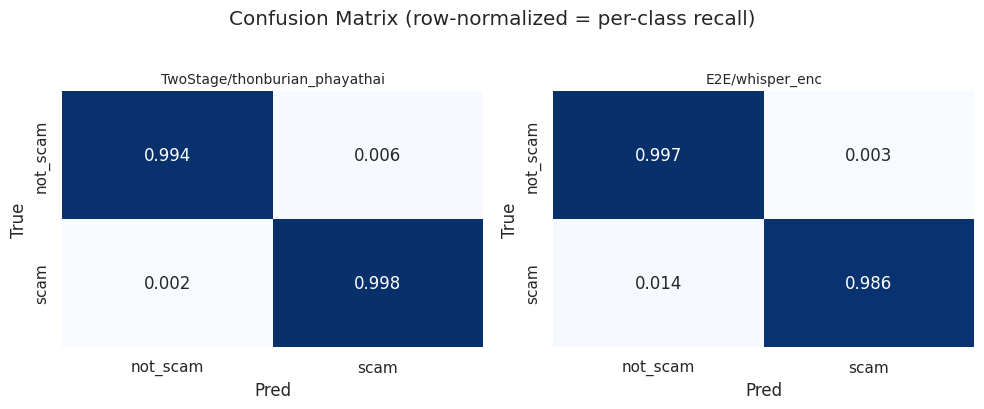

In [ ]:
# === Confusion matrices: top-4 models ===
top_models = summary.head(4)['model'].tolist()
fig, axes = plt.subplots(1, len(top_models), figsize=(5*len(top_models), 4))
if len(top_models) == 1: axes = [axes]
for ax, name in zip(axes, top_models):
    d = predictions[name]
    cm = confusion_matrix(d.label, d.pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.3f', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cbar=False, vmin=0, vmax=1)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Pred'); ax.set_ylabel('True')
plt.suptitle('Confusion Matrix (row-normalized = per-class recall)', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/cm_top_models.png', dpi=150, bbox_inches='tight')
plt.show()

# 🚩 ถ้าทุก diagonal ใกล้ 1.0 ใน top models = น่าสงสัย

In [ ]:
train_names = set(train_df.filename)
test_names  = set(test_df.filename)
val_names   = set(splits['val'].filename)

overlap_train_test = train_names & test_names
overlap_train_val  = train_names & val_names
overlap_val_test   = val_names & test_names

print(f'train ∩ test:  {len(overlap_train_test)}  {"🚩" if overlap_train_test else "✅"}')
print(f'train ∩ val:   {len(overlap_train_val)}   {"🚩" if overlap_train_val else "✅"}')
print(f'val ∩ test:    {len(overlap_val_test)}    {"🚩" if overlap_val_test else "✅"}')

if overlap_train_test:
    print('\n🚩 LEAK FOUND! examples:')
    for f in list(overlap_train_test)[:5]:
        print(f'  {f}')

train ∩ test:  0  ✅
train ∩ val:   0   ✅
val ∩ test:    0    ✅


In [ ]:
# เช็คว่า transcript ของ ASR แต่ละตัวมี filename ปนมาไหม
import re
from pathlib import Path

TRANSCRIPTS_DIR = f'{DRIVE_BASE}/transcripts'
if os.path.exists(TRANSCRIPTS_DIR):
    for asr_name in os.listdir(TRANSCRIPTS_DIR):
        tr_path = f'{TRANSCRIPTS_DIR}/{asr_name}/test.csv'
        if not os.path.exists(tr_path):
            continue
        tr = pd.read_csv(tr_path)
        tr['text'] = tr['text'].fillna('').astype(str)
        # นับ transcript ที่มี 'label' หรือ 'conv_' หรือเลข index
        leak_patterns = tr.text.str.contains(r'label[01]|conv_\d+', regex=True, na=False)
        n_leak = int(leak_patterns.sum())
        flag = ' 🚩' if n_leak > 0 else ' ✅'
        print(f'  {asr_name}: {n_leak}/{len(tr)} transcripts มี filename pattern{flag}')
else:
    print('(ไม่มี transcripts folder — skip)')

  thonburian: 0/2129 transcripts มี filename pattern ✅


In [ ]:
# === Load transcripts + tokenize (Thai) ===
!pip install -q pythainlp

from pythainlp.tokenize import word_tokenize

TRANSCRIPTS_DIR_PATH = f'{DRIVE_BASE}/transcripts/thonburian'
tr_train = pd.read_csv(f'{TRANSCRIPTS_DIR_PATH}/train.csv')
tr_test  = pd.read_csv(f'{TRANSCRIPTS_DIR_PATH}/test.csv')
tr_train['text'] = tr_train['text'].fillna('').astype(str)
tr_test['text']  = tr_test['text'].fillna('').astype(str)

print(f'Train transcripts: {len(tr_train)}')
print(f'Test transcripts:  {len(tr_test)}')

# Tokenize ทั้งหมด (cache เพื่อความเร็ว)
def tokenize_th(text):
    if not text:
        return []
    return [w for w in word_tokenize(text, engine='newmm') if w.strip()]

print('\nTokenizing...')
tr_train['tokens'] = [tokenize_th(t) for t in tqdm(tr_train.text, desc='train')]
tr_test['tokens']  = [tokenize_th(t) for t in tqdm(tr_test.text,  desc='test')]

# Stats เบื้องต้น
tr_train['n_tokens'] = tr_train.tokens.apply(len)
tr_test['n_tokens']  = tr_test.tokens.apply(len)

print(f'\n=== Token count ต่อ sample ===')
print(f'Train: mean={tr_train.n_tokens.mean():.1f}, median={tr_train.n_tokens.median():.0f}')
print(f'Test:  mean={tr_test.n_tokens.mean():.1f}, median={tr_test.n_tokens.median():.0f}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 118.7 MB/s eta 0:00:00
Train transcripts: 17029
Test transcripts:  2129

Tokenizing...


train:   0%|          | 0/17029 [00:00<?, ?it/s]

test:   0%|          | 0/2129 [00:00<?, ?it/s]


=== Token count ต่อ sample ===
Train: mean=30.2, median=32
Test:  mean=30.1, median=32


In [ ]:
# === Distinct-N (Lexical Diversity) — per class ===
from collections import Counter

def distinct_n(tokens_list, n=1):
    """tokens_list: list of token lists → return ratio of unique n-grams"""
    all_ngrams = []
    for tokens in tokens_list:
        for i in range(len(tokens) - n + 1):
            all_ngrams.append(tuple(tokens[i:i+n]))
    if not all_ngrams:
        return 0.0, 0, 0
    return len(set(all_ngrams)) / len(all_ngrams), len(set(all_ngrams)), len(all_ngrams)

print('=== Distinct-N: Train ===')
print(f'{"":<20} {"D-1":>8} {"D-2":>8} {"D-3":>8}   {"unique/total":>22}')
for cls_id, cls_name in [(0, 'not_scam'), (1, 'scam'), (None, 'overall')]:
    if cls_id is None:
        tokens_list = tr_train.tokens.tolist()
    else:
        tokens_list = tr_train[tr_train.label == cls_id].tokens.tolist()

    line = f'{cls_name:<20} '
    detail = ''
    for n in [1, 2, 3]:
        d, uniq, total = distinct_n(tokens_list, n=n)
        flag = ' 🚩' if (n == 2 and d < 0.1) else ''
        line += f'{d:>7.4f}{flag} '
        if n == 2:
            detail = f'   ({uniq:,} / {total:,})'
    print(line + detail)

print('\n=== Distinct-N: Test ===')
print(f'{"":<20} {"D-1":>8} {"D-2":>8} {"D-3":>8}')
for cls_id, cls_name in [(0, 'not_scam'), (1, 'scam'), (None, 'overall')]:
    if cls_id is None:
        tokens_list = tr_test.tokens.tolist()
    else:
        tokens_list = tr_test[tr_test.label == cls_id].tokens.tolist()
    line = f'{cls_name:<20} '
    for n in [1, 2, 3]:
        d, _, _ = distinct_n(tokens_list, n=n)
        flag = ' 🚩' if (n == 2 and d < 0.1) else ''
        line += f'{d:>7.4f}{flag} '
    print(line)

print('\n💡 Distinct-2 < 0.1 = ซ้ำๆ มาก  | > 0.3 = หลากหลาย')

=== Distinct-N: Train ===
                          D-1      D-2      D-3             unique/total
not_scam              0.0155  0.1640  0.4039    (39,600 / 241,480)
scam                  0.0112  0.1121  0.2899    (28,718 / 256,159)
overall               0.0098  0.1200  0.3259    (59,706 / 497,639)

=== Distinct-N: Test ===
                          D-1      D-2      D-3
not_scam              0.0529  0.3376  0.6043 
scam                  0.0396  0.2567  0.4975 
overall               0.0350  0.2645  0.5258 

💡 Distinct-2 < 0.1 = ซ้ำๆ มาก  | > 0.3 = หลากหลาย


In [ ]:
# === Exact duplicate transcripts + Cross-set overlap ===
print('=== Exact Duplicate Transcripts ===\n')

# Within train
dup_train = tr_train[tr_train.text.duplicated(keep=False) & (tr_train.text.str.len() > 5)]
print(f'Train: {len(dup_train)}/{len(tr_train)} ({len(dup_train)/len(tr_train)*100:.1f}%) เป็น duplicate')

# Within test
dup_test = tr_test[tr_test.text.duplicated(keep=False) & (tr_test.text.str.len() > 5)]
print(f'Test:  {len(dup_test)}/{len(tr_test)} ({len(dup_test)/len(tr_test)*100:.1f}%) เป็น duplicate')

# Per class
print('\nDuplicate counts per class (train):')
for cls_id, cls_name in [(0, 'not_scam'), (1, 'scam')]:
    sub = tr_train[tr_train.label == cls_id]
    n_dup = sub[sub.text.duplicated(keep=False) & (sub.text.str.len() > 5)].shape[0]
    flag = ' 🚩' if n_dup / len(sub) > 0.2 else ''
    print(f'  {cls_name}: {n_dup}/{len(sub)} ({n_dup/len(sub)*100:.1f}%){flag}')

# Cross-set overlap
print('\n=== Cross-set Text Overlap ===')
train_texts = set(tr_train[tr_train.text.str.len() > 5].text)
test_texts  = set(tr_test [tr_test.text.str.len()  > 5].text)
overlap_text = train_texts & test_texts

print(f'Train unique texts: {len(train_texts):,}')
print(f'Test  unique texts: {len(test_texts):,}')
print(f'Overlap:            {len(overlap_text):,}', end='')

if len(overlap_text) > 0:
    pct = len(overlap_text) / len(test_texts) * 100
    flag = ' 🚩' if pct > 5 else ''
    print(f' ({pct:.1f}% ของ test texts){flag}')
    print('\nตัวอย่าง overlap text:')
    for t in list(overlap_text)[:5]:
        print(f'  "{t[:80]}..."')
else:
    print(' ✅')

# Top 10 most repeated text in train
print('\n=== Top 10 most repeated transcripts (train) ===')
top_dup = tr_train[tr_train.text.str.len() > 5].text.value_counts().head(10)
for txt, n in top_dup.items():
    print(f'  ×{n:>4}: "{txt[:80]}..."')

=== Exact Duplicate Transcripts ===

Train: 22/17029 (0.1%) เป็น duplicate
Test:  0/2129 (0.0%) เป็น duplicate

Duplicate counts per class (train):
  not_scam: 14/8924 (0.2%)
  scam: 8/8105 (0.1%)

=== Cross-set Text Overlap ===
Train unique texts: 17,014
Test  unique texts: 2,129
Overlap:            1 (0.0% ของ test texts)

ตัวอย่าง overlap text:
  "สวัสดีครับคุณครับ..."

=== Top 10 most repeated transcripts (train) ===
  ×   6: "ไงเว้ยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยย..."
  ×   3: "คุณได้รับรหัสยืนยันสำหรับการรีเซ็ตหัดผ่านของคุณคือ หนึ่งแสนสองหมื่นสามพันสี่ร้อย..."
  ×   3: "เฮ้ย แกได้ยินไหม มันมีเสียง..."
  ×   2: "รหัสยืนยันตัวตนของคุณคือ หนึ่งแสนสองหมื่นสามพันสี่ร้อยห้าสิบหกกรุณา อย่าแบ่งปันร..."
  ×   2: "เฮ้ยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยยย..."
  ×   2: "เฮ้ย แกได้ยินไหม เสียงมัน..."
  ×   2: "อ้าว สวัสดีครับ คุณสมชายใช่ไหมครับ..."
  ×   2: "ฮัลโหล สวัสดีครับ คุณสมชายใช่ไหมครับ..."
  ×   1: "ไงเ

=== Within-class Pairwise TF-IDF Cosine Similarity ===

(สูง = transcripts ภายใน class ซ้ำกัน ; ต่ำ = หลากหลาย)

  not_scam     (n=500)
    mean sim:      0.0918
    median sim:    0.0669
    % pairs > 0.7: 0.0%
    % pairs > 0.9: 0.0%

  scam         (n=500)
    mean sim:      0.1227
    median sim:    0.1024
    % pairs > 0.7: 0.0%
    % pairs > 0.9: 0.0%



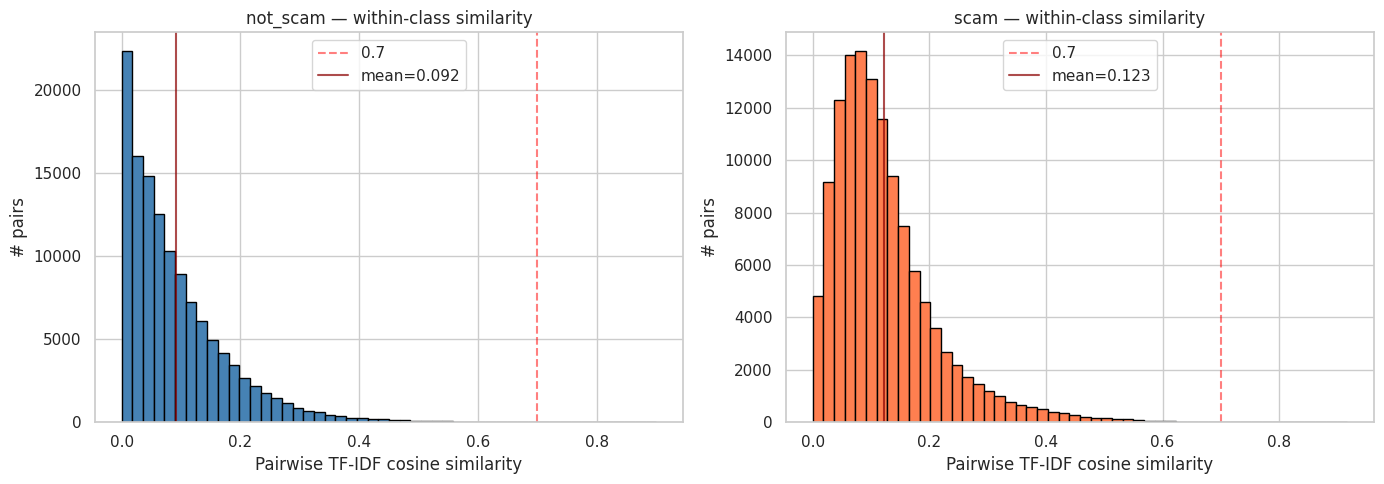

In [ ]:
# === Within-class pairwise TF-IDF similarity ===
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

SAMPLE_PER_CLASS = 500   # sample เพื่อความเร็ว (pairwise = O(n²))

print('=== Within-class Pairwise TF-IDF Cosine Similarity ===\n')
print('(สูง = transcripts ภายใน class ซ้ำกัน ; ต่ำ = หลากหลาย)\n')

results_within = {}
for cls_id, cls_name in [(0, 'not_scam'), (1, 'scam')]:
    sub = tr_train[tr_train.label == cls_id].copy()
    sub = sub[sub.text.str.len() > 5]

    if len(sub) > SAMPLE_PER_CLASS:
        sub = sub.sample(SAMPLE_PER_CLASS, random_state=42)

    vec = TfidfVectorizer(tokenizer=lambda t: tokenize_th(t),
                          max_features=10000, min_df=2)
    X = vec.fit_transform(sub.text)
    sim = cosine_similarity(X)

    # upper triangle (exclude diagonal)
    n = len(sim)
    pairs = sim[np.triu_indices(n, k=1)]

    results_within[cls_name] = {
        'mean':   float(pairs.mean()),
        'median': float(np.median(pairs)),
        'pct_gt_0.7': float((pairs > 0.7).mean()),
        'pct_gt_0.9': float((pairs > 0.9).mean()),
    }

    flag_mean = ' 🚩' if pairs.mean() > 0.5 else ''
    flag_high = ' 🚩' if (pairs > 0.7).mean() > 0.2 else ''
    print(f'  {cls_name:<12} (n={n})')
    print(f'    mean sim:      {pairs.mean():.4f}{flag_mean}')
    print(f'    median sim:    {np.median(pairs):.4f}')
    print(f'    % pairs > 0.7: {(pairs > 0.7).mean()*100:.1f}%{flag_high}')
    print(f'    % pairs > 0.9: {(pairs > 0.9).mean()*100:.1f}%')
    print()

# Plot histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (cls_id, cls_name) in zip(axes, [(0, 'not_scam'), (1, 'scam')]):
    sub = tr_train[tr_train.label == cls_id].copy()
    sub = sub[sub.text.str.len() > 5]
    if len(sub) > SAMPLE_PER_CLASS:
        sub = sub.sample(SAMPLE_PER_CLASS, random_state=42)
    vec = TfidfVectorizer(tokenizer=lambda t: tokenize_th(t), max_features=10000, min_df=2)
    X = vec.fit_transform(sub.text)
    sim = cosine_similarity(X)
    pairs = sim[np.triu_indices(len(sim), k=1)]

    ax.hist(pairs, bins=50, color='steelblue' if cls_id == 0 else 'coral', edgecolor='black')
    ax.axvline(0.7, color='red', linestyle='--', alpha=0.5, label='0.7')
    ax.axvline(pairs.mean(), color='darkred', linestyle='-', alpha=0.7, label=f'mean={pairs.mean():.3f}')
    ax.set_xlabel('Pairwise TF-IDF cosine similarity')
    ax.set_ylabel('# pairs')
    ax.set_title(f'{cls_name} — within-class similarity')
    ax.legend()

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/text_pairwise_sim.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# === Vocabulary size + summary ===
print('=== Vocabulary Statistics ===\n')

for cls_id, cls_name in [(0, 'not_scam'), (1, 'scam'), (None, 'overall')]:
    if cls_id is None:
        sub = tr_train
    else:
        sub = tr_train[tr_train.label == cls_id]
    all_tokens = [t for tokens in sub.tokens for t in tokens]
    unique_words = len(set(all_tokens))
    print(f'  {cls_name:<12}  unique words: {unique_words:>6,}  total tokens: {len(all_tokens):>9,}  '
          f'avg/sample: {len(all_tokens)/len(sub):.1f}')

# Summary จุดที่พบ — text diversity
print('\n' + '='*60)
print('📊 TEXT DIVERSITY SUMMARY')
print('='*60)

# Distinct-2 (overall)
overall_d2, _, _ = distinct_n(tr_train.tokens.tolist(), n=2)

text_diversity_summary = {
    'distinct_2_train_overall':  float(overall_d2),
    'distinct_2_train_not_scam': float(distinct_n(tr_train[tr_train.label==0].tokens.tolist(), n=2)[0]),
    'distinct_2_train_scam':     float(distinct_n(tr_train[tr_train.label==1].tokens.tolist(), n=2)[0]),
    'exact_duplicate_train_pct': float(len(dup_train) / len(tr_train) * 100),
    'cross_set_text_overlap':    int(len(overlap_text)),
    'cross_set_overlap_pct':     float(len(overlap_text) / len(test_texts) * 100) if len(test_texts) > 0 else 0,
    'within_class_sim_not_scam': results_within['not_scam']['mean'],
    'within_class_sim_scam':     results_within['scam']['mean'],
}

# Save to summary file
text_div_path = f'{OUT_DIR}/text_diversity.json'
with open(text_div_path, 'w', encoding='utf-8') as f:
    json.dump(text_diversity_summary, f, indent=2, ensure_ascii=False)

print(json.dumps(text_diversity_summary, indent=2, ensure_ascii=False))
print(f'\n✅ Saved → {text_div_path}')

# Interpretation
print('\n💡 Interpretation:')
if overall_d2 < 0.1:
    print('  🚩 Distinct-2 ต่ำมาก = transcript ซ้ำๆ กันมาก → confirm dataset diversity ต่ำที่ระดับ text')
elif overall_d2 < 0.3:
    print('  ⚠️ Distinct-2 ปานกลาง = มีความหลากหลายบ้าง แต่ไม่สูง')
else:
    print('  ✅ Distinct-2 สูง = text หลากหลาย → ปัญหา F1 อาจไม่ใช่จาก text repetition')

if len(overlap_text) / max(len(test_texts), 1) > 0.05:
    print('  🚩 Test transcripts > 5% มีตัวเดียวกันกับ train → text-level leakage!')

if results_within['scam']['mean'] > 0.5 or results_within['not_scam']['mean'] > 0.5:
    print('  🚩 Within-class sim สูง = ภายใน class มี template ซ้ำๆ')

=== Vocabulary Statistics ===

  not_scam      unique words:  3,891  total tokens:   250,404  avg/sample: 28.1
  scam          unique words:  2,961  total tokens:   264,263  avg/sample: 32.6
  overall       unique words:  5,061  total tokens:   514,667  avg/sample: 30.2

📊 TEXT DIVERSITY SUMMARY
{
  "distinct_2_train_overall": 0.1199785386595504,
  "distinct_2_train_not_scam": 0.1639887361272155,
  "distinct_2_train_scam": 0.11211005664450595,
  "exact_duplicate_train_pct": 0.129191379411592,
  "cross_set_text_overlap": 1,
  "cross_set_overlap_pct": 0.046970408642555195,
  "within_class_sim_not_scam": 0.09181965683631127,
  "within_class_sim_scam": 0.12274469023964536
}

✅ Saved → /content/drive/MyDrive/ThaiScamCall/runs/phase1_diagnostics/text_diversity.json

💡 Interpretation:
  ⚠️ Distinct-2 ปานกลาง = มีความหลากหลายบ้าง แต่ไม่สูง


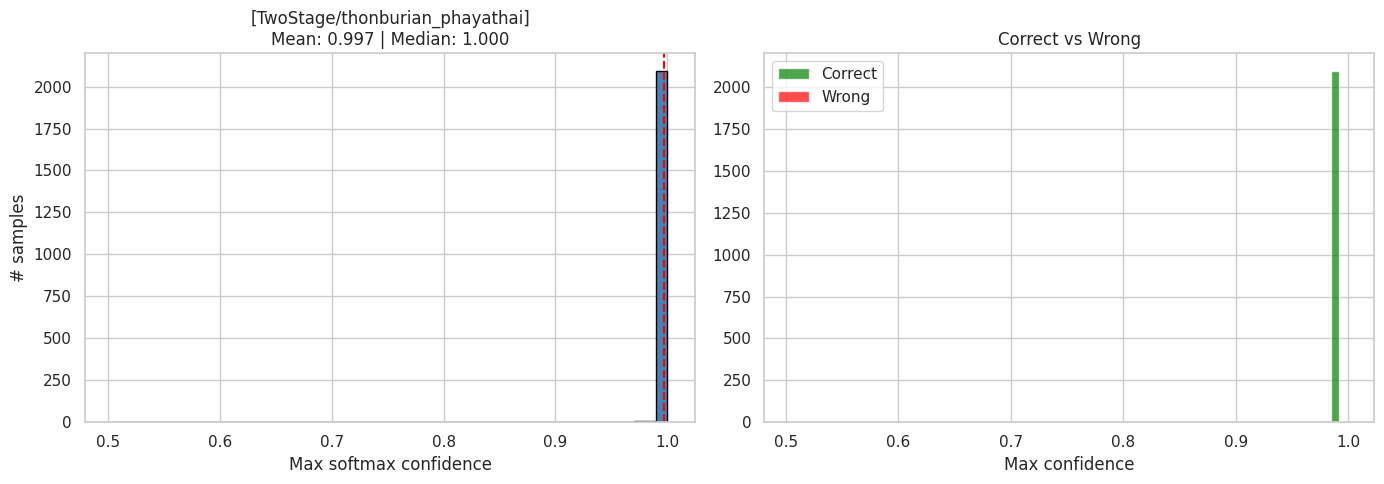

% confidence > 0.99: 98.3%
% confidence > 0.95: 99.0%
🚩 WARNING: >80% prediction confidence > 0.99 — น่าสงสัย


In [ ]:
d = predictions[FOCUS_MODEL]
# สร้าง max_conf จาก prob_scam (binary)
p_scam = d.prob_scam.values
max_conf = np.where(d.pred.values == 1, p_scam, 1 - p_scam)
correct_mask = (d.pred == d.label).values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(max_conf, bins=50, edgecolor='black', color='steelblue')
axes[0].set_xlabel('Max softmax confidence')
axes[0].set_ylabel('# samples')
axes[0].set_title(f'[{FOCUS_MODEL}]\nMean: {max_conf.mean():.3f} | Median: {np.median(max_conf):.3f}')
axes[0].axvline(max_conf.mean(), color='red', linestyle='--')

axes[1].hist([max_conf[correct_mask], max_conf[~correct_mask]],
             bins=30, label=['Correct', 'Wrong'], color=['green', 'red'], alpha=0.7)
axes[1].set_xlabel('Max confidence')
axes[1].set_title('Correct vs Wrong')
axes[1].legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/confidence_dist_{FOCUS_MODEL.replace("/", "_")}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'% confidence > 0.99: {(max_conf > 0.99).mean() * 100:.1f}%')
print(f'% confidence > 0.95: {(max_conf > 0.95).mean() * 100:.1f}%')
if (max_conf > 0.99).mean() > 0.8:
    print('🚩 WARNING: >80% prediction confidence > 0.99 — น่าสงสัย')

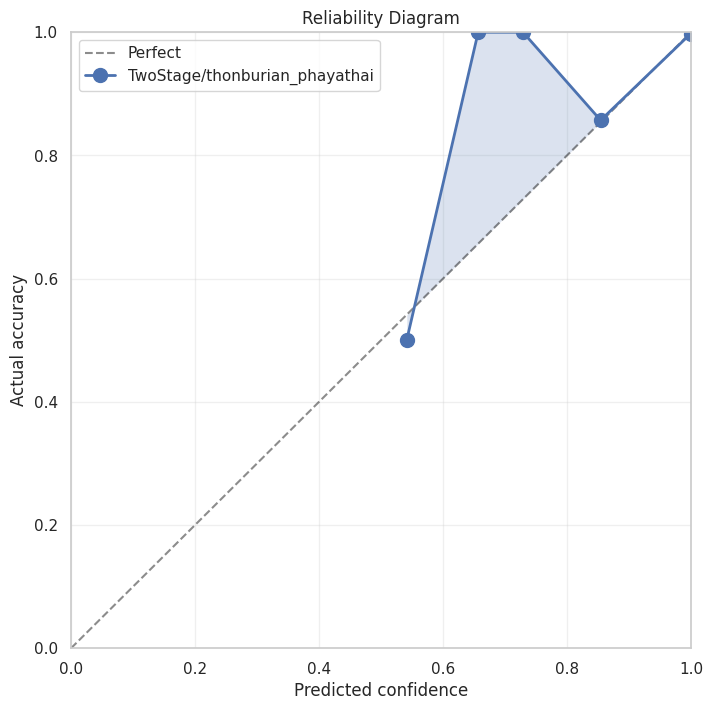

ECE: 0.0024  ✅ Well calibrated


In [ ]:
# Reliability diagram + ECE
correct = (d.pred == d.label).astype(int).values
prob_true, prob_pred = calibration_curve(correct, max_conf, n_bins=10, strategy='uniform')

plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
plt.plot(prob_pred, prob_true, marker='o', lw=2, markersize=10, label=FOCUS_MODEL)
plt.fill_between(prob_pred, prob_pred, prob_true, alpha=0.2)
plt.xlabel('Predicted confidence'); plt.ylabel('Actual accuracy')
plt.title('Reliability Diagram')
plt.legend(); plt.xlim(0,1); plt.ylim(0,1); plt.grid(alpha=0.3)
plt.savefig(f'{OUT_DIR}/calibration_{FOCUS_MODEL.replace("/", "_")}.png', dpi=150, bbox_inches='tight')
plt.show()

def ece(correct, conf, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    e = 0.0
    for i in range(n_bins):
        m = (conf > bins[i]) & (conf <= bins[i+1])
        if m.sum() > 0:
            e += (m.sum()/len(conf)) * abs(correct[m].mean() - conf[m].mean())
    return e

e = ece(correct, max_conf)
print(f'ECE: {e:.4f}', end='  ')
if e < 0.05:  print('✅ Well calibrated')
elif e < 0.15: print('⚠️  Moderate miscalibration')
else:         print('🚩 Poor calibration')

In [ ]:
d = predictions[FOCUS_MODEL]
errors = d[d.pred != d.label].copy()
errors['confidence'] = np.where(errors.pred == 1, errors.prob_scam, 1 - errors.prob_scam)
errors['true_class']  = errors.label.map({0: 'not_scam', 1: 'scam'})
errors['pred_class']  = errors.pred.map({0: 'not_scam', 1: 'scam'})
errors = errors.sort_values('confidence', ascending=False)

err_rate = len(errors) / len(d)
print(f'[{FOCUS_MODEL}] Error rate: {len(errors)}/{len(d)} ({err_rate*100:.2f}%)')
if err_rate < 0.02:
    print('🚩 WARNING: Error rate ต่ำมาก (<2%) — น่าสงสัย')

# Save errors
errors.to_csv(f'{OUT_DIR}/errors_{FOCUS_MODEL.replace("/", "_")}.csv', index=False)

print('\nTop 15 high-confidence errors:')
errors[['filename', 'true_class', 'pred_class', 'confidence']].head(15)

[TwoStage/thonburian_phayathai] Error rate: 9/2129 (0.42%)
🚩 WARNING: Error rate ต่ำมาก (<2%) — น่าสงสัย

Top 15 high-confidence errors:


,filename,true_class,pred_class,confidence
1874,conv_16895_label1.mp3,scam,not_scam,0.995618
1841,conv_00298_label0.mp3,not_scam,scam,0.988906
950,conv_03242_label1.mp3,scam,not_scam,0.979996
834,conv_13868_label0.mp3,not_scam,scam,0.940243
601,conv_13008_label0.mp3,not_scam,scam,0.903123
1721,conv_11346_label0.mp3,not_scam,scam,0.893959
920,conv_11435_label0.mp3,not_scam,scam,0.594787
1132,conv_05411_label0.mp3,not_scam,scam,0.578880
46,conv_17009_label0.mp3,not_scam,scam,0.505154


In [ ]:
# Error pattern
if len(errors) > 0:
    pattern = errors.groupby(['true_class', 'pred_class']).size().reset_index(name='count')
    print('Error pattern:')
    print(pattern.to_string(index=False))

Error pattern:
true_class pred_class  count
  not_scam       scam      7
      scam   not_scam      2


In [ ]:
# ฟังเคส high-confidence error 5 อัน
import IPython.display as ipd

for _, row in errors.head(5).iterrows():
    print('─'*60)
    print(f"True: {row['true_class']} | Pred: {row['pred_class']} | Conf: {row['confidence']:.3f}")
    print(f"File: {row['filename']}")
    ipd.display(ipd.Audio(f'{EXTRACT_DIR}/{row["filename"]}'))

────────────────────────────────────────────────────────────
True: scam | Pred: not_scam | Conf: 0.996
File: conv_16895_label1.mp3


────────────────────────────────────────────────────────────
True: not_scam | Pred: scam | Conf: 0.989
File: conv_00298_label0.mp3


────────────────────────────────────────────────────────────
True: scam | Pred: not_scam | Conf: 0.980
File: conv_03242_label1.mp3


────────────────────────────────────────────────────────────
True: not_scam | Pred: scam | Conf: 0.940
File: conv_13868_label0.mp3


────────────────────────────────────────────────────────────
True: not_scam | Pred: scam | Conf: 0.903
File: conv_13008_label0.mp3


In [ ]:
summary_dict = {
    'focus_model':           FOCUS_MODEL,
    'flagged_models':        flagged,
    'n_models_evaluated':    len(predictions),
    # Split integrity
    'filename_overlap_train_test':  len(overlap_train_test),
    # Text diversity (Section E)
    'distinct_2_train_overall':     float(overall_d2),
    'distinct_2_train_not_scam':    text_diversity_summary['distinct_2_train_not_scam'],
    'distinct_2_train_scam':        text_diversity_summary['distinct_2_train_scam'],
    'exact_duplicate_train_pct':    text_diversity_summary['exact_duplicate_train_pct'],
    'cross_set_text_overlap':       text_diversity_summary['cross_set_text_overlap'],
    'cross_set_overlap_pct':        text_diversity_summary['cross_set_overlap_pct'],
    'within_class_sim_not_scam':    text_diversity_summary['within_class_sim_not_scam'],
    'within_class_sim_scam':        text_diversity_summary['within_class_sim_scam'],
    # Focus model metrics
    'focus_accuracy':        float(accuracy_score(d.label, d.pred)),
    'focus_macro_f1':        float(f1_score(d.label, d.pred, average='macro')),
    'focus_mean_confidence': float(max_conf.mean()),
    'focus_pct_conf_gt_99':  float((max_conf > 0.99).mean()),
    'focus_ece':             float(e),
    'focus_error_rate':      float(err_rate),
    # Baseline ref
    'majority_baseline_acc': float(baseline_acc),
}

with open(f'{OUT_DIR}/summary.json', 'w') as f:
    json.dump(summary_dict, f, indent=2, ensure_ascii=False)

summary.to_csv(f'{OUT_DIR}/all_models_metrics.csv', index=False)

print(f'✅ Saved to {OUT_DIR}/')
print('  - summary.json (diagnosis สำหรับ report mentor)')
print('  - all_models_metrics.csv (เทียบทุก model)')
print('  - text_diversity.json (Distinct-N, pairwise sim)')
print('  - text_pairwise_sim.png')
print('  - errors_<focus>.csv')
print('  - *.png (calibration, confusion)')
print()
print(json.dumps(summary_dict, indent=2, ensure_ascii=False))

✅ Saved to /content/drive/MyDrive/ThaiScamCall/runs/phase1_diagnostics/
  - summary.json (diagnosis สำหรับ report mentor)
  - all_models_metrics.csv (เทียบทุก model)
  - text_diversity.json (Distinct-N, pairwise sim)
  - text_pairwise_sim.png
  - errors_<focus>.csv
  - *.png (calibration, confusion)

{
  "focus_model": "TwoStage/thonburian_phayathai",
  "flagged_models": [
    "TwoStage/thonburian_phayathai",
    "E2E/whisper_enc"
  ],
  "n_models_evaluated": 2,
  "filename_overlap_train_test": 0,
  "distinct_2_train_overall": 0.1199785386595504,
  "distinct_2_train_not_scam": 0.1639887361272155,
  "distinct_2_train_scam": 0.11211005664450595,
  "exact_duplicate_train_pct": 0.129191379411592,
  "cross_set_text_overlap": 1,
  "cross_set_overlap_pct": 0.046970408642555195,
  "within_class_sim_not_scam": 0.09181965683631127,
  "within_class_sim_scam": 0.12274469023964536,
  "focus_accuracy": 0.9957726632221701,
  "focus_macro_f1": 0.9957636870978503,
  "focus_mean_confidence": 0.997076133